# 02. Stylometric Analysis

This notebook extracts a conservative set of **19 stylometric features**.

## Overview
1. Load Corpus
2. Extract Feature Matrix
3. Sanity check
4. Category-by-Category Feature Demonstration
5. Dimensionality Reduction
6. Save Outputs

In [2]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

from src.analysis import StylometricAnalyzer
from src.visualization import StylometricPlotter

## 1. Load Corpus

In [3]:
corpus_path = Path('../data/raw/corpus.json')

with open(corpus_path, 'r') as f:
    corpus = json.load(f)

print(f"Loaded {len(corpus)} generated texts")

Loaded 360 generated texts


## 2. Extract Feature Matrix

We extract the **feature set** of 19 features used throughout the main analysis and classification pipeline.

In [4]:
analyzer = StylometricAnalyzer()

texts      = [item['generated_text'] for item in corpus]
labels     = [item['model']          for item in corpus]
genres     = [item['genre']          for item in corpus]
prompt_ids = [item['prompt_id']      for item in corpus]
runs       = [item['run']            for item in corpus]

feature_df = analyzer.analyze_corpus(
    texts, labels=labels, genres=genres, prompt_ids=prompt_ids, runs=runs,
)

print(f"Extracted {len(feature_df.columns) - 4} features from {len(feature_df)} texts")

Extracted 19 features from 360 texts


## 3. Sanity Check

In [5]:
_meta = ('label', 'genre', 'prompt_id', 'run')
feature_cols = [c for c in feature_df.columns if c not in _meta]

print(f"Texts:    {len(feature_df)}")
print(f"Models:   {sorted(feature_df['label'].unique())}")
print(f"Genres:   {sorted(feature_df['genre'].unique())}")
print(f"Prompts:  {feature_df['prompt_id'].nunique()}")
print(f"Features: {len(feature_cols)}")
print(f"Columns:  {feature_cols}")

Texts:    360
Models:   ['gpt-4-turbo', 'llama3', 'mistral']
Genres:   ['argumentation', 'description', 'dialogue', 'narration']
Prompts:  40
Features: 19
Columns:  ['type_token_ratio', 'hapax_legomena_ratio', 'avg_word_length', 'stop_word_ratio', 'bigram_uniqueness_ratio', 'trigram_uniqueness_ratio', 'gunning_fog_index', 'avg_sentence_length', 'sentence_length_std', 'pos_noun_ratio', 'pos_verb_ratio', 'pos_adj_ratio', 'pos_adv_ratio', 'avg_syntactic_depth', 'comma_ratio', 'question_mark_ratio', 'discourse_total_ratio', 'paragraph_count', 'avg_paragraph_length']


## 4. Category-by-Category Feature Demonstration

For each feature category we show a summary table (mean per model) and a violin plot. This section demonstrates that the extraction pipeline covers every dimension required by the project brief.

In [6]:
plotter = StylometricPlotter()

# Helper: show mean table + violin for a category
def show_category(title, features):
    print(f"--- {title} ---")
    display(feature_df.groupby('label')[features].mean().round(4))
    plotter.plot_feature_comparison(feature_df, features, plot_type='violin')

### 4.1 Lexical Diversity

Measures how varied and rich the vocabulary is. TTR and hapax ratio capture vocabulary breadth; n-gram uniqueness captures phrasal originality; stop-word ratio reflects function-word density.

--- Lexical Diversity ---


,type_token_ratio,hapax_legomena_ratio,avg_word_length,stop_word_ratio,bigram_uniqueness_ratio,trigram_uniqueness_ratio
label,,,,,,
gpt-4-turbo,0.5399,0.4072,4.8912,0.4873,0.9210,0.9881
llama3,0.5574,0.4074,4.7766,0.5033,0.9086,0.9756
mistral,0.5673,0.4257,5.0511,0.4636,0.9226,0.9826


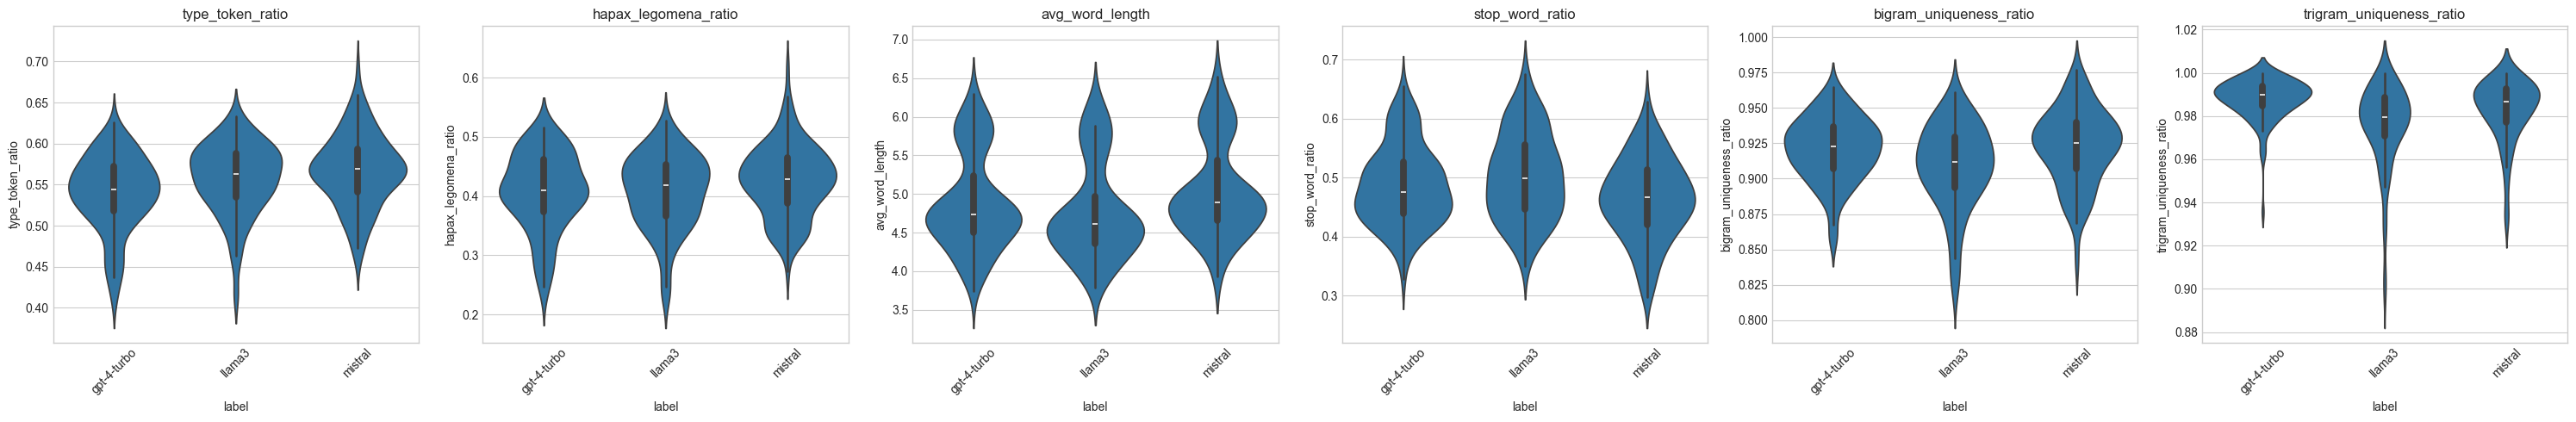

In [7]:
show_category("Lexical Diversity", [
    'type_token_ratio', 'hapax_legomena_ratio', 'avg_word_length',
    'stop_word_ratio', 'bigram_uniqueness_ratio', 'trigram_uniqueness_ratio',
])

### 4.2 Readability

The Gunning Fog index estimates the years of formal education needed to understand a text on first reading. It combines average sentence length with the proportion of complex (≥ 3 syllable) words.

--- Readability ---


,gunning_fog_index
label,
gpt-4-turbo,13.6147
llama3,12.9507
mistral,14.7348


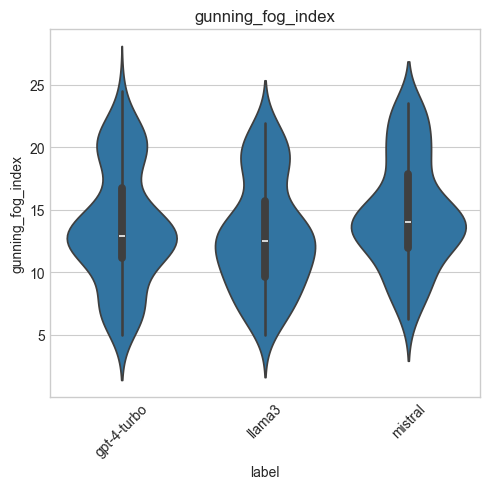

In [8]:
show_category("Readability", ['gunning_fog_index'])

### 4.3 Sentence and Paragraph Structure

Average sentence length and its standard deviation capture whether a model favours uniform or varied sentence structures. Paragraph-level features reflect structural formatting choices.

--- Sentence / Phraseology ---


,avg_sentence_length,sentence_length_std,paragraph_count,avg_paragraph_length
label,,,,
gpt-4-turbo,18.5184,6.7819,9.5333,57.9221
llama3,18.7455,5.9626,7.0667,52.8179
mistral,19.3080,6.4839,8.1417,50.8306


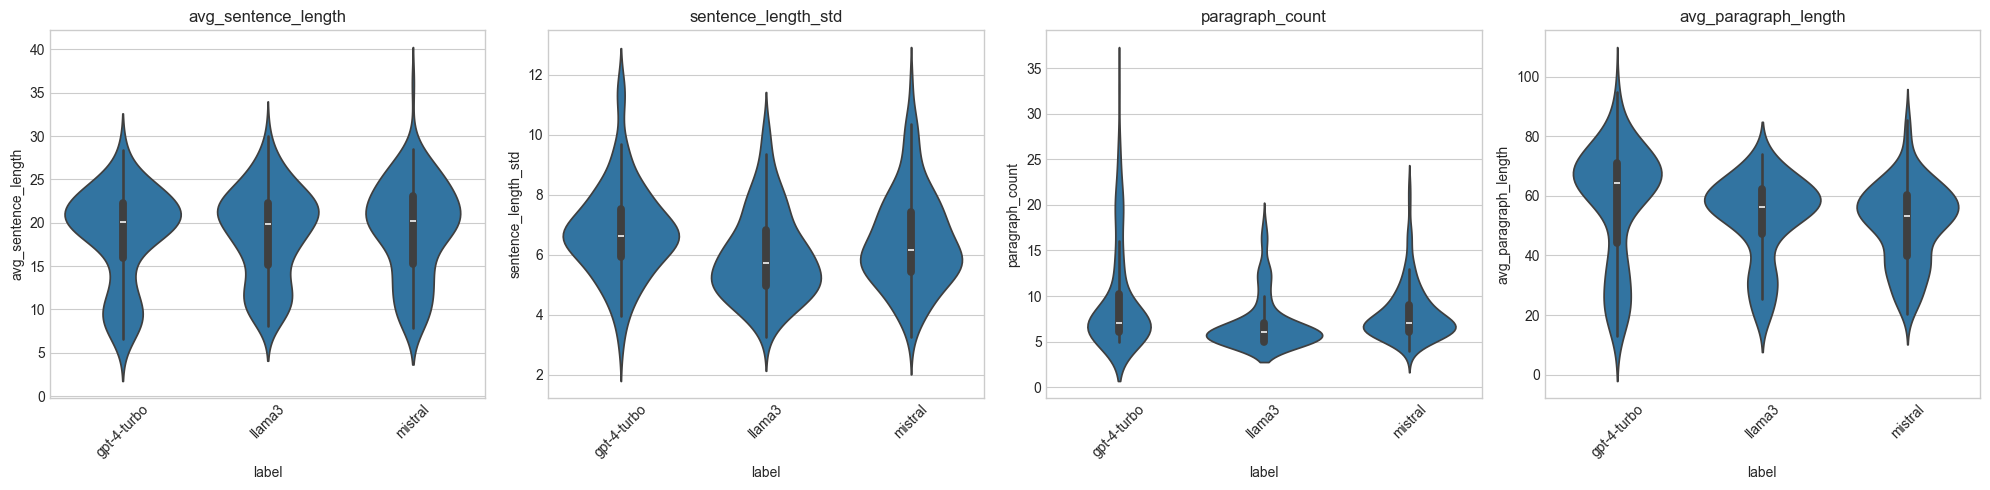

In [9]:
show_category("Sentence / Phraseology", [
    'avg_sentence_length', 'sentence_length_std',
    'paragraph_count', 'avg_paragraph_length',
])

### 4.4 POS Ratios

Part-of-speech distributions are a classic stylometric signal. Higher adjective/adverb ratios suggest more descriptive writing; noun/verb balance reflects information density vs. action orientation.

--- POS Ratios ---


,pos_noun_ratio,pos_verb_ratio,pos_adj_ratio,pos_adv_ratio
label,,,,
gpt-4-turbo,0.2217,0.1145,0.0867,0.0423
llama3,0.2158,0.1217,0.0779,0.0384
mistral,0.2305,0.1195,0.0807,0.0337


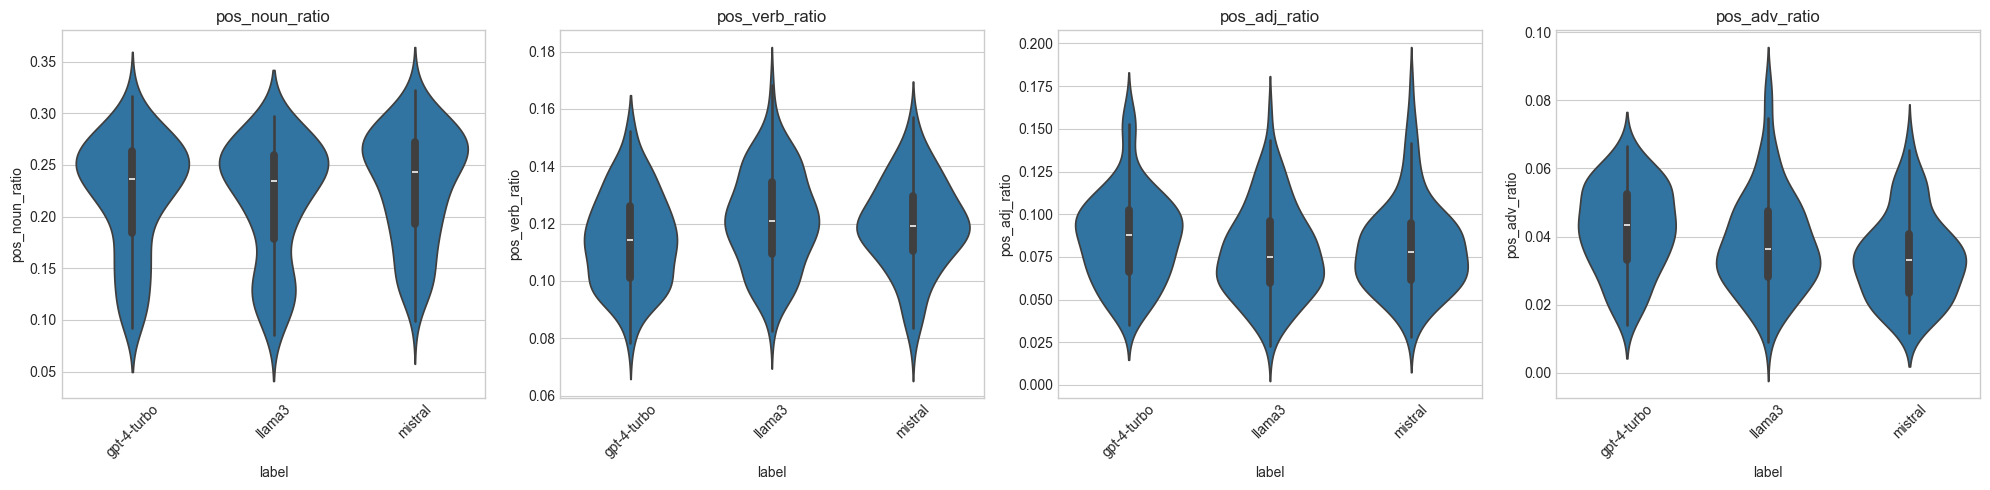

In [10]:
show_category("POS Ratios", [
    'pos_noun_ratio', 'pos_verb_ratio', 'pos_adj_ratio', 'pos_adv_ratio',
])

### 4.5 Syntactic Depth

Average dependency-tree depth measures how deeply nested syntactic structures are. Higher depth suggests more complex, embedded sentence construction.

--- Syntactic Depth ---


,avg_syntactic_depth
label,
gpt-4-turbo,2.7794
llama3,2.6824
mistral,2.8658


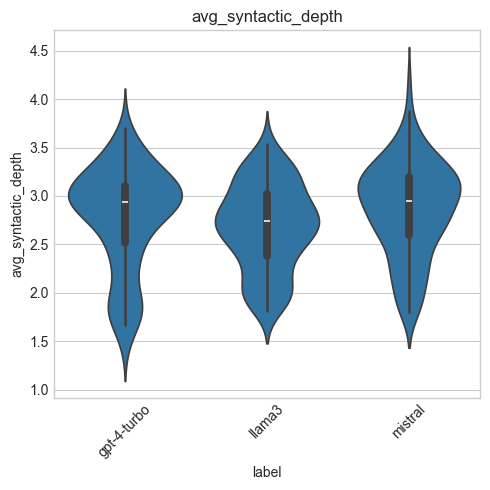

In [11]:
show_category("Syntactic Depth", ['avg_syntactic_depth'])

### 4.6 Punctuation

Comma and question-mark frequency (per sentence) capture stylistic habits in clause structuring and rhetorical questioning.

--- Punctuation ---


,comma_ratio,question_mark_ratio
label,,
gpt-4-turbo,1.4616,0.0500
llama3,1.3042,0.0584
mistral,1.5002,0.0330


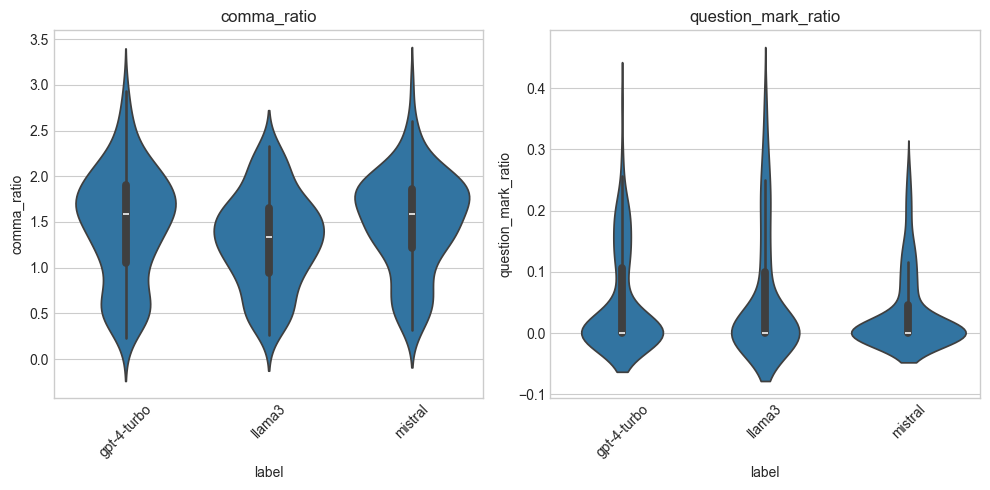

In [12]:
show_category("Punctuation", ['comma_ratio', 'question_mark_ratio'])

### 4.7 Discourse Markers

`discourse_total_ratio` is the density of connective words (*however*, *moreover*, *because*, *then*, etc.) across all categories. This captures a model's cohesion strategy independent of any single marker type. Paragraph structure is shown above under sentence/phraseology (4.3).

--- Discourse Markers ---


,discourse_total_ratio
label,
gpt-4-turbo,0.0144
llama3,0.0119
mistral,0.0118


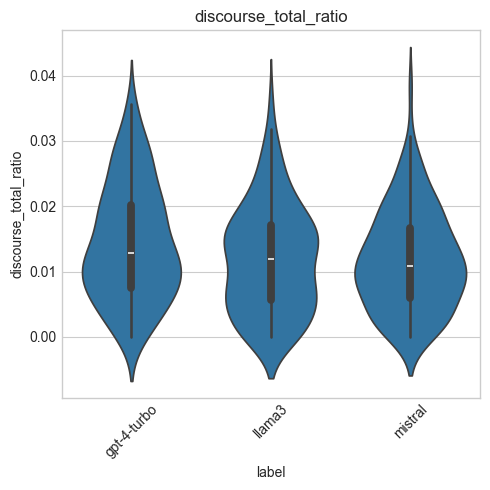

In [13]:
show_category("Discourse Markers", ['discourse_total_ratio'])

## 5. Dimensionality Reduction

Features are **standardised** (zero mean, unit variance) before PCA and t-SNE so that high-magnitude columns do not dominate the embedding. These plots are exploratory visualisations of how models cluster in feature space.

### 5.1 PCA

Explained variance: PC1=45.52%, PC2=16.18%


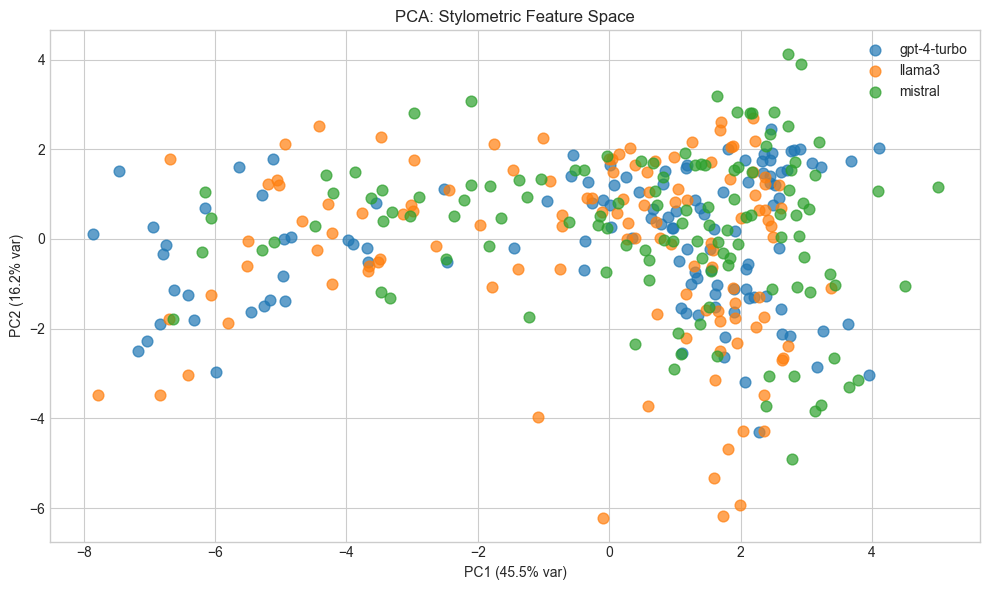

In [14]:
# PCA coloured by model
df_pca = feature_df[feature_cols + ['label']]
fig, pca = plotter.plot_pca(df_pca, label_col='label')
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

Explained variance: PC1=45.52%, PC2=16.18%


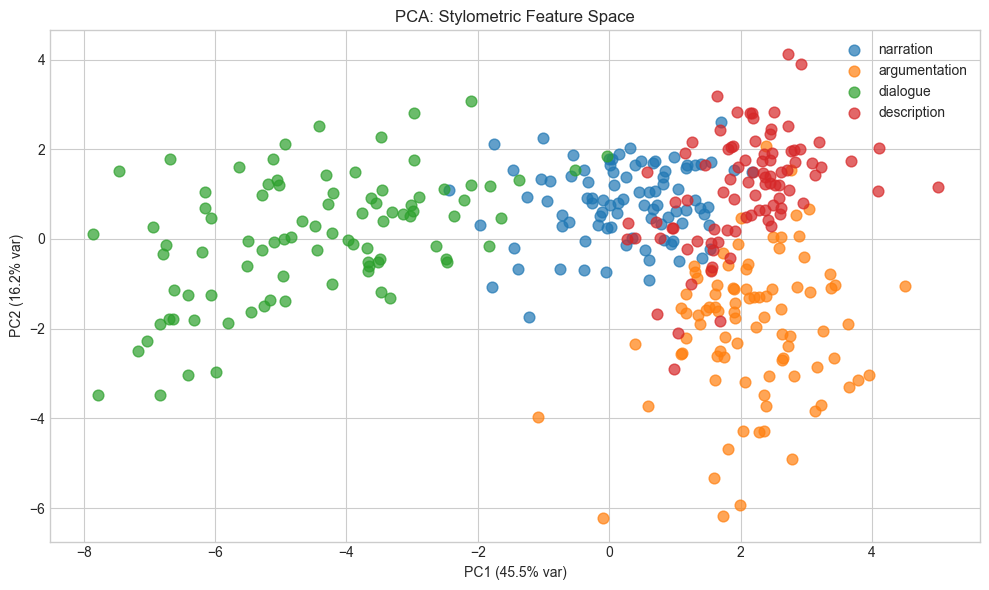

In [15]:
# PCA coloured by genre
df_pca_g = feature_df[feature_cols + ['genre']]
fig, pca_g = plotter.plot_pca(df_pca_g, label_col='genre')
print(f"Explained variance: PC1={pca_g.explained_variance_ratio_[0]:.2%}, PC2={pca_g.explained_variance_ratio_[1]:.2%}")

### 5.2 t-SNE

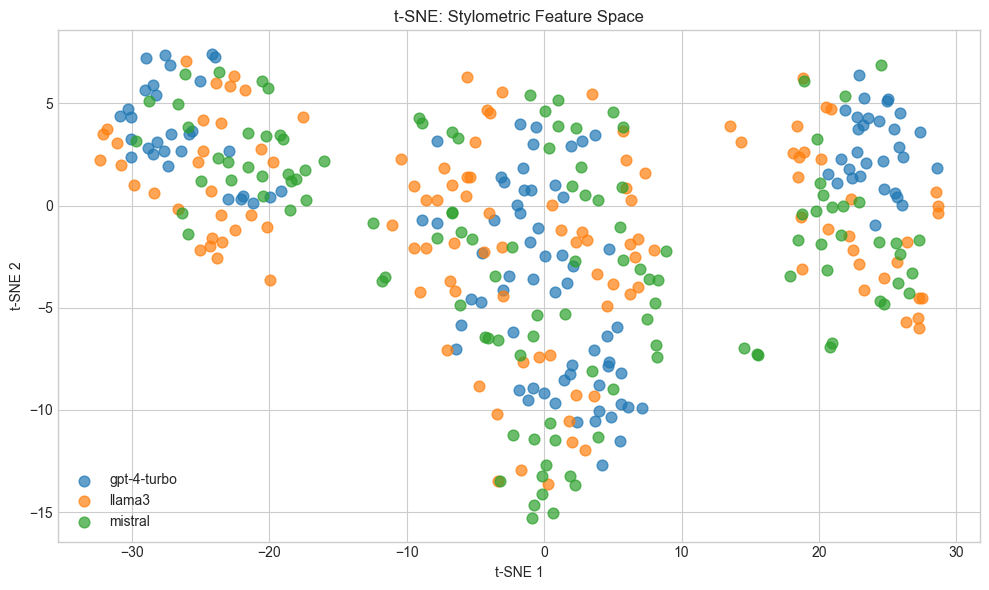

In [16]:
df_tsne = feature_df[feature_cols + ['label']]
plotter.plot_tsne(df_tsne, label_col='label');

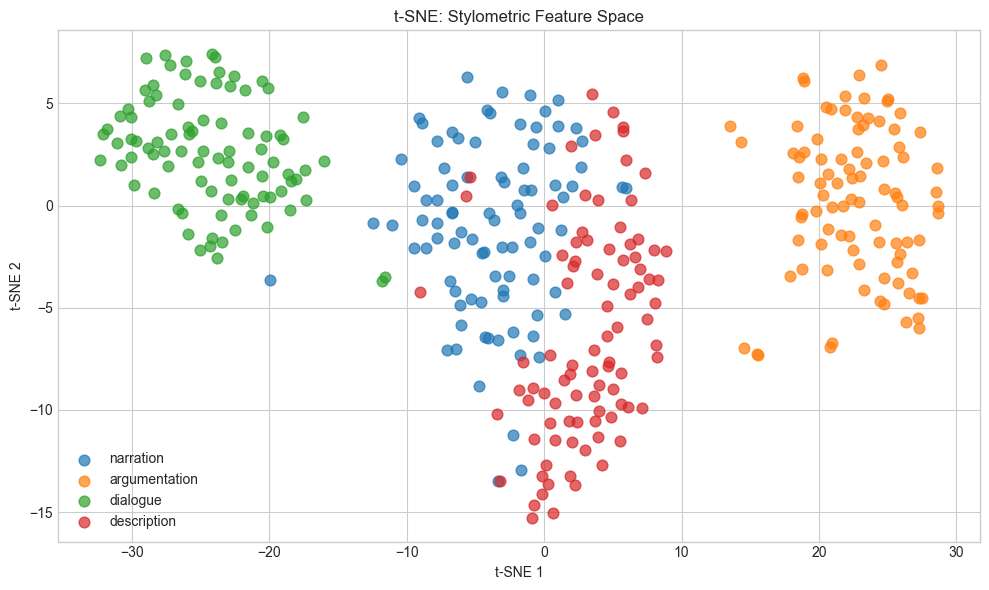

In [17]:
df_tsne_g = feature_df[feature_cols + ['genre']]
plotter.plot_tsne(df_tsne_g, label_col='genre');

## 6. Save Outputs

In [18]:
output_path = Path('../data/processed')
output_path.mkdir(exist_ok=True)

feature_df[feature_cols] = (
    feature_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

feature_df.to_csv(output_path / 'features.csv', index=False)
print(f"Saved features.csv            {feature_df.shape}")

Saved features.csv            (360, 23)
